### Reasons to prefer CNN over ANN for Images
**Reasons why we move from a simple** ANN (Artificial Neural Network)** to a **CNN (Convolutional Neural Network)** for image classification:


1. **Too many parameters in ANN**

   * Flattening an image into a 1D vector leads to massive weight matrices.
   * Example: A 224×224×3 image → \~150,000 pixels. If connected to 1,000 hidden neurons = **150M weights** just in the first layer.

2. **Loss of spatial structure**

   * ANN treats each pixel as independent.
   * It doesn’t “know” which pixels are neighbors, so it cannot naturally learn edges or shapes.
  * In **ANN**, we take a 28×28 image (784 pixels) and **flatten** it into a 1D vector.
  * After flattening, pixel `(row 5, col 5)` sits right next to pixel `(row 20, col 13)` in the vector — even though they are far apart in the image.
  * ANN **does not know** which pixels were neighbors in the original 2D grid.
  * So: **spatial structure (who’s next to who) is lost.**

3. **Poor generalization (no translation invariance)**

   * ANN can fail if the object shifts slightly in position.
   * CNN’s sliding filters detect features **anywhere in the image**, so they generalize better.
   

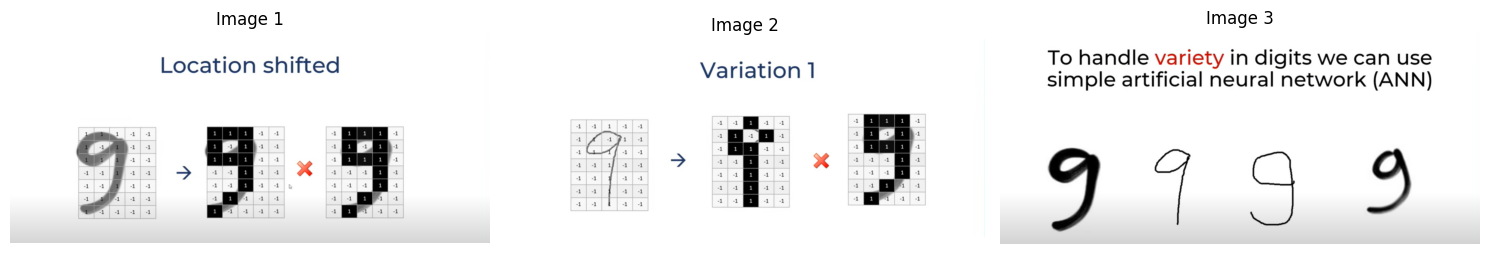

In [2]:
import requests
from PIL import Image
from io import BytesIO

import matplotlib.pyplot as plt

urls = [
    "https://drive.google.com/uc?export=view&id=1IXB9Ib_2uHJ8We94eJQ9V6hDww-gG15y",
    "https://drive.google.com/uc?export=view&id=1bskAKRdVbKGcghatL6D77tc8WeuEJq59",
    "https://drive.google.com/uc?export=view&id=1L74pE7gM0snuu5aQ20gMsWJncE-tgXml",
]

images = []
for u in urls:
    r = requests.get(u)
    r.raise_for_status()
    images.append(Image.open(BytesIO(r.content)).convert("RGB"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, i in zip(axes, images, range(1, 4)):
    ax.imshow(img)
    ax.set_title(f"Image {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

---

### Why ANN struggles with handwriting variety

**But** for **handwritten digit recognition**, ANNs don’t handle **spatial variety** (shifts, rotations, style variations) very well. That’s why **Convolutional Neural Networks (CNNs)** became the standard — CNNs can automatically detect edges, curves, and spatial hierarchies, making them much better at recognizing digits across handwriting variations.

1. **No spatial awareness**: ANN flattens images into vectors, so the relationship between neighboring pixels is lost.

2. **High parameter count**: A 28×28 image = 784 inputs → requires many weights → hard to generalize.

3. **Not robust to shifts/rotations**: A slightly shifted “9” may look like a different vector to the 
ANN.

4. **Overfitting risk in ANN**

   * With so many parameters, ANN memorizes training data instead of learning general patterns.
   * CNN reduces parameters through **weight sharing** and **local connections**, lowering overfitting.

5. **Hierarchical feature learning in CNNs**

   * Early CNN layers learn **edges & corners**.
   * Middle layers learn **patterns & textures**.
   * Deeper layers learn **object parts (faces, wheels, wings, etc.)**.
   * ANN lacks this structured feature extraction.

6. **Efficiency**

   * CNN’s convolution operation + parameter sharing means faster training and less memory usage compared to ANN on image tasks.

---

👉 In short:
**ANNs are dense and flat (good for tabular data)**, while **CNNs are structured and efficient (good for images and spatial data)**.

---


---
# Section 1: Introduction to CNNs
----


## 🌟 What is a CNN?

A **Convolutional Neural Network (CNN or ConvNet)** is a special type of neural network designed to work with data that has a **grid-like structure**, such as images.

* Unlike traditional **Artificial Neural Networks (ANNs)**, which treat every pixel as independent, CNNs make use of the **spatial structure** of images — meaning they understand that nearby pixels are related (for example, pixels forming an edge, a corner, or a texture).
* CNNs are especially powerful for **image classification, object detection, and recognition tasks**.

---

## 🔑 Key Concepts in CNNs

### 1. **Convolution**

* Convolution is the **mathematical operation** at the heart of CNNs.
* It involves sliding a small window (called a **filter**) across the image and computing a weighted sum of pixel values.
* Instead of looking at the entire image at once, CNNs look at **small local regions** (like a patch of 3×3 pixels).
* This helps detect local patterns such as **edges, lines, or textures** in the image.

---

### 2. **Filters / Kernels**

* A **filter** (also called a **kernel**) is a small matrix of numbers (like 3×3 or 5×5) that is multiplied with the input pixels.
* Each filter learns to detect a specific feature (e.g., horizontal edges, vertical edges, color contrasts, or curves).
* CNNs don’t rely on **manually designed filters** — instead, the **filters are learned automatically during training**.

---

### 3. **Feature Maps**

* After applying a filter to an image, the result is called a **feature map**.
* A feature map highlights the areas where the filter has detected something important (e.g., an edge or texture).
* Stacking multiple feature maps allows the CNN to build a **hierarchy of features**:

  * Early layers → detect simple edges or corners.
  * Middle layers → detect shapes or textures.
  * Deeper layers → detect complex objects (like a face, car, or digit).

---

### 4. **Padding & Stride**

* **Padding**: Sometimes, when a filter is applied, the edges of the image get ignored. To prevent loss of information at the borders, we add extra pixels (often zeros) around the image — this is called **padding**.
* **Stride**: Stride defines **how far the filter moves** each time (e.g., stride of 1 = move by 1 pixel, stride of 2 = move by 2 pixels).

  * Larger stride → smaller output size (faster, but less detail).
  * Smaller stride → larger output size (slower, but more detail).

---

### 5. **Pooling (Max / Average)**

* Pooling is used to **reduce the size** of feature maps while keeping the important information.
* It makes the network **faster, less memory-hungry, and more robust** to small shifts in the input image.
* Types:

  * **Max Pooling**: Takes the maximum value in a patch (keeps strongest feature).
  * **Average Pooling**: Takes the average value in a patch (smooths out features).

---

### 6. **Fully Connected Layers (FC Layers)**

* After several rounds of convolution and pooling, the CNN extracts **high-level features** from the image.
* These features are then fed into a **fully connected neural network layer**, similar to a traditional ANN.
* The FC layers combine all learned features and make the **final prediction** (e.g., whether the image is a cat, dog, or airplane).

---

✅ **In summary:**

* **Convolution + Filters** → detect features.
* **Feature Maps** → highlight patterns.
* **Padding & Stride** → control output size and edge handling.
* **Pooling** → reduce size and make model robust.
* **Fully Connected Layers** → final decision-making.

---

---
![](https://drive.google.com/uc?export=view&id=1TklD1_hBknj4BhC1L6yqKeDlMoCmb6g_)




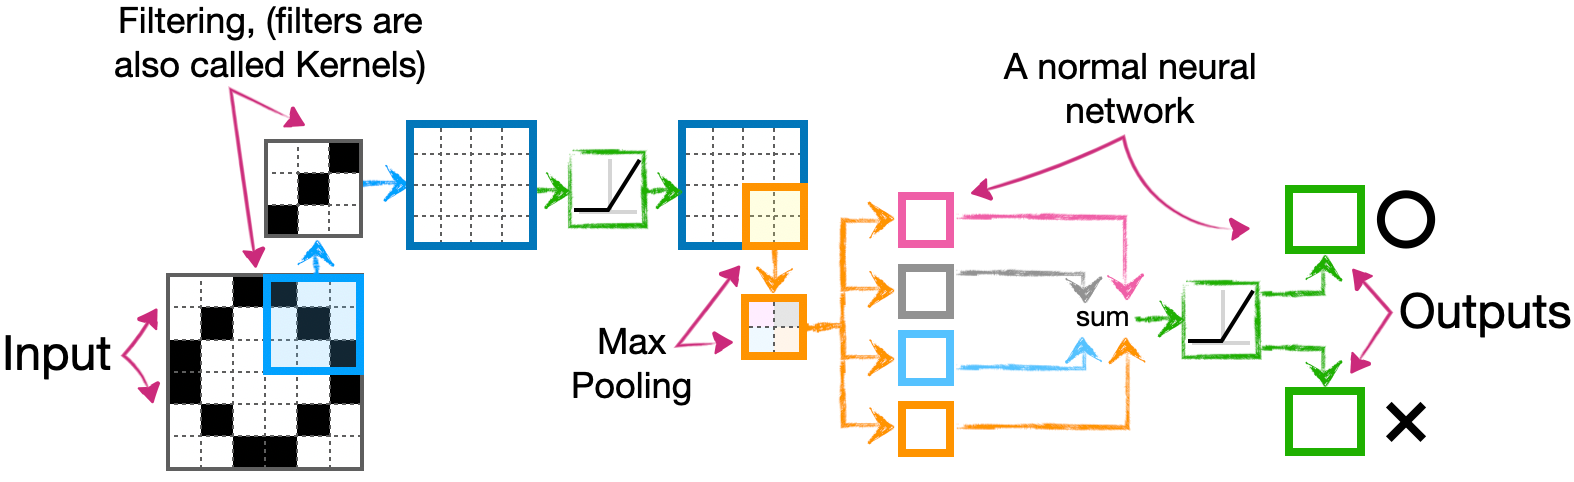

[Deep Learning Tutorial](https://www.youtube.com/watch?v=zfiSAzpy9NM)

---
# Section 2: Setting up the Environment
---




First, we need to import the necessary libraries. We'll use TensorFlow and Keras, which are excellent for building and training neural networks.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


---
# Section 3: The Architecture of a Simple CNN
---

Let's define a simple CNN model. We'll use the Sequential API from Keras. Our model will consist of a few convolutional layers followed by pooling layers, and finally a fully connected layer for classification.

In [ ]:
def create_cnn_model():
    model = models.Sequential()

    # Layer 1: Convolutional Layer
    # - 32 filters, each of size (3, 3)
    # - ReLU activation
    # - input_shape for the first layer (e.g., a 28x28 grayscale image)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

    # Layer 2: Pooling Layer
    # - Reduces the feature map size by taking the maximum value in a (2, 2) window.
    model.add(layers.MaxPooling2D((2, 2)))

    # Layer 3: Another Convolutional Layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))

    # Layer 4: Another Pooling Layer
    model.add(layers.MaxPooling2D((2, 2)))

    # Layer 5: Flatten the output
    # - This converts the 2D feature maps into a 1D vector, which can be fed into a
    #   fully connected layer.
    model.add(layers.Flatten())

    # Layer 6: Fully Connected Layer
    # - 64 neurons with ReLU activation
    model.add(layers.Dense(64, activation='relu'))

    # Layer 7: Output Layer
    # - 10 neurons (for 10 classes, e.g., digits 0-9) with softmax activation
    # - Softmax ensures the output is a probability distribution over the classes.
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Create and display the model summary
model = create_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

---
Section 4: Loading and Preprocessing the Data
---

We'll use the MNIST dataset, a classic dataset of handwritten digits, perfect for demonstrating a basic CNN.


In [ ]:
# Load the data
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Preprocess the data
# - Reshape the images to add a channel dimension (for grayscale, it's 1).
# - Normalize the pixel values to be between 0 and 1.
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
# Section 5: Training the CNN
---

In [ ]:
# Compile the model
# - **Optimizer:** 'adam' is a popular choice for many tasks. It adjusts the learning rate.
# - **Loss Function:** 'sparse_categorical_crossentropy' is suitable for multi-class
#   classification with integer labels.
# - **Metrics:** 'accuracy' to monitor the model's performance during training.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
# - **epochs:** The number of times the model will see the entire training dataset.
# - **validation_data:** Used to evaluate the model on a separate dataset,
#   helping to detect overfitting.
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.8982 - loss: 0.3242 - val_accuracy: 0.9827 - val_loss: 0.0543
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 28ms/step - accuracy: 0.9848 - loss: 0.0485 - val_accuracy: 0.9877 - val_loss: 0.0382
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9885 - val_loss: 0.0344
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9892 - val_loss: 0.0380
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9949 - loss: 0.0164 - val_accuracy: 0.9894 - val_loss: 0.0320


---
# Section 6: Evaluating the Model
---

313/313 - 2s - 8ms/step - accuracy: 0.9894 - loss: 0.0320

Test accuracy: 0.9894000291824341


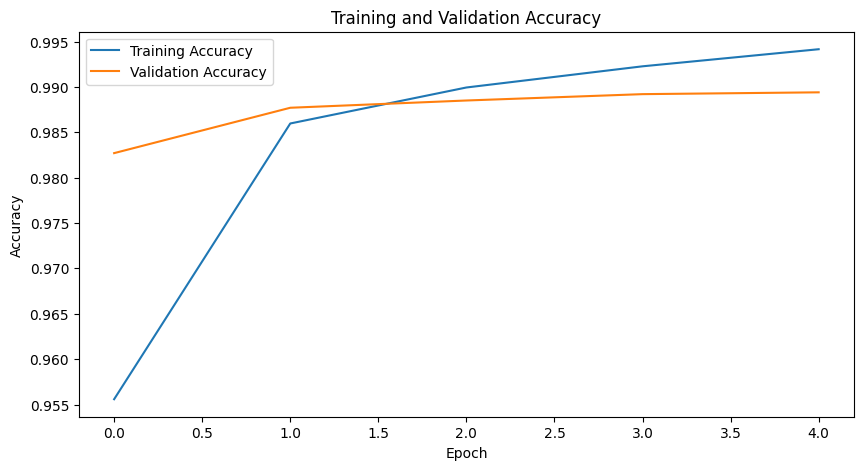

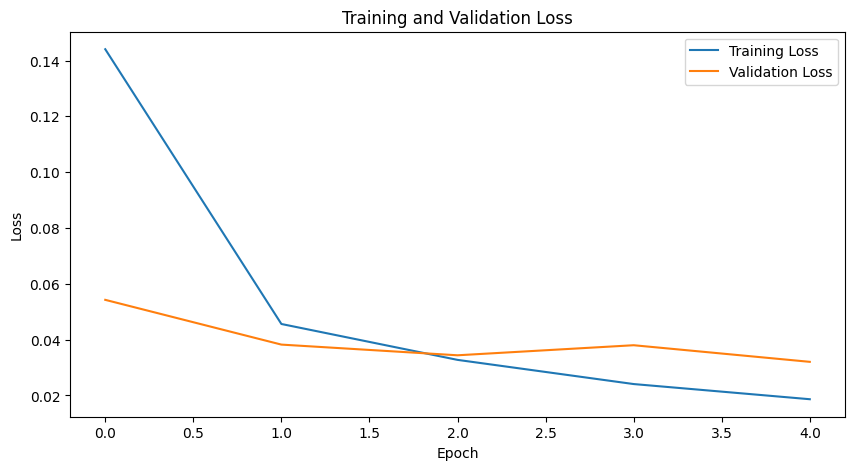

In [ ]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("\nTest accuracy:", test_acc)

# Plot training and validation accuracy over epochs
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

---
# Section 7: Making Predictions
---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


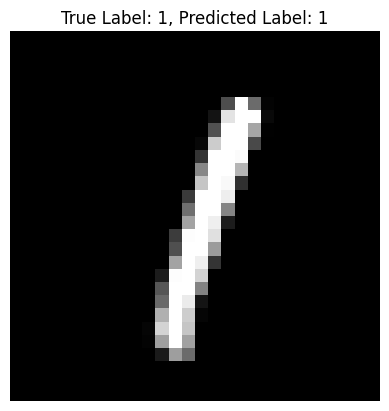

In [ ]:
# Let's make a prediction on a single image from the test set.

# Select an image
image_index = 5
test_image = test_images[image_index]
true_label = test_labels[image_index]

# Add a batch dimension to the image (since the model expects a batch)
test_image_batch = np.expand_dims(test_image, axis=0)

# Get the prediction
predictions = model.predict(test_image_batch)
predicted_label = np.argmax(predictions[0])

# Display the image and prediction
plt.imshow(test_image.reshape(28, 28), cmap='gray')
plt.title(f'True Label: {true_label}, Predicted Label: {predicted_label}')
plt.axis('off')
plt.show()


In [ ]:
# End of Notebook
print("This notebook provided an overview of CNNs, their architecture, and a hands-on example.")
print("Feel free to experiment with different parameters, such as the number of layers, filters, or epochs!")

This notebook provided an overview of CNNs, their architecture, and a hands-on example.
Feel free to experiment with different parameters, such as the number of layers, filters, or epochs!
